# Lab 1: KNN

Explore the data, implement a KNN algorithm and evaluate the results. This is the first lab, please select 6 random digits, this ID is your name for the rest of the course so please save it to use for other labs and exams. Submit this notebook to eclass with the name "lab1_123456.ipynb" and replace "123456" by your ID.

Import libraries

In [1]:
#%pip install -U scikit-learn
#%pip install matplotlib
#%pip install pandas

In [2]:

import numpy as np
from sklearn import datasets
from sklearn import model_selection
import matplotlib.pyplot as plt

In [3]:
data = datasets.load_iris()
#print(len(data.target))
#print(data.data.shape)
#print(data.target)
#print(data.target_names)

Import the data using datasets.load_iris(), check the output of the function. Read the documentation to choose how you want to import the dataset.

In [4]:
X = data.data 
y = data.target

Important, play with your variables. Check the shape of X and y to see if they have they make sense.Variable y should contain the labels for datapoints in X, check the labels and how many differnt labels there are.

In [5]:
print("==================================================")
print(X.shape)
print(y.shape)
print("==================================================")
print(data.feature_names)
print(X[0:5])
print("==================================================")
print(data.target_names)
print(y[0:5])
print("==================================================")
print("size of each class")
print(np.bincount(y))
print("==================================================")

(150, 4)
(150,)
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
['setosa' 'versicolor' 'virginica']
[0 0 0 0 0]
size of each class
[50 50 50]


Select two columns of X to plot each datapoint in a 2Dimensional space. Make sure that datapoint of the same class have the same color, and datapoints of different class have different colors (see scatter() function from matplotlib). Examine visually which pair of features better separate the flowers into the different classes. Add labels to the x and y axis of each plot in the subplot.

In [6]:
#select two columns: sepal length and sepal width
X_plot = X[:, :2]
print(X_plot.shape)

(150, 2)


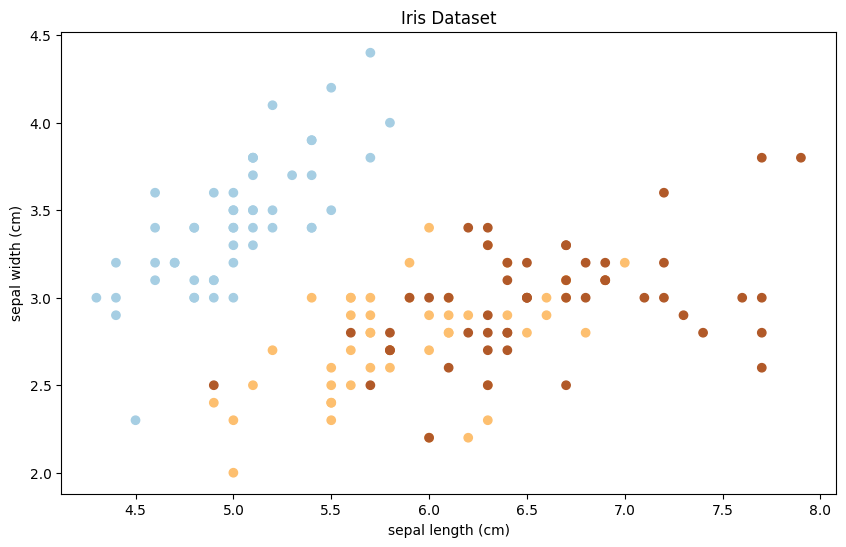

In [7]:
# first: give a visualization of the data
plt.figure(figsize=(10, 6))
plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y, cmap=plt.cm.Paired)
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title("Iris Dataset")
plt.show()

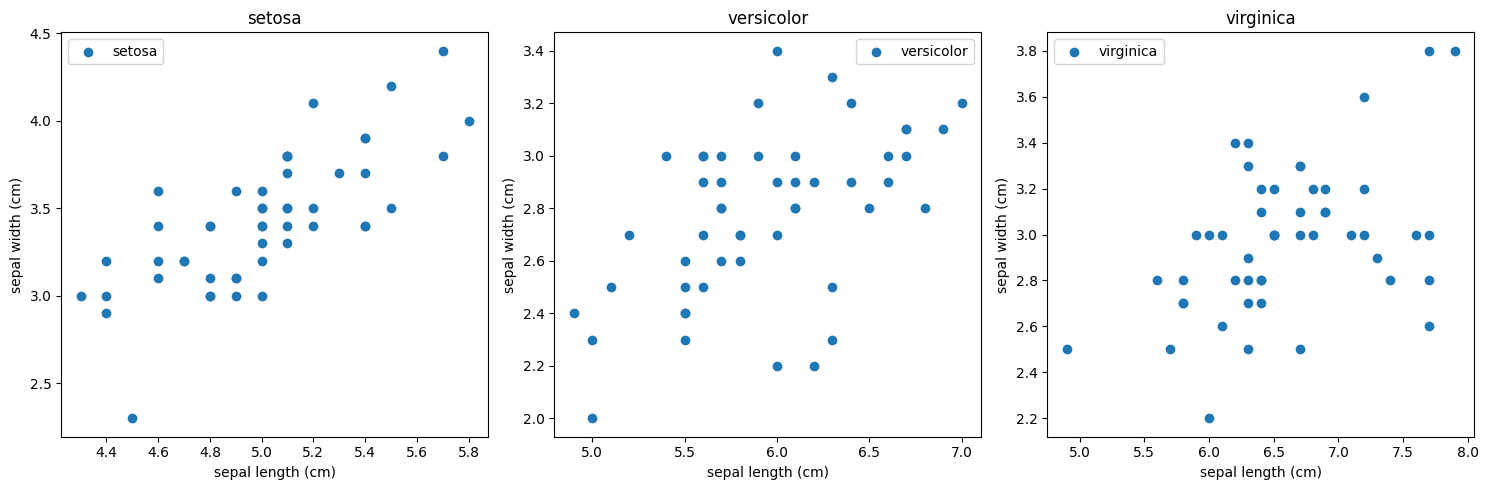

In [8]:
# second: give a visualization of each class in subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    axes[i].scatter(X[y == i, 0], X[y == i, 1], label=data.target_names[i])
    axes[i].set_title(data.target_names[i])
    axes[i].set_xlabel(data.feature_names[0])
    axes[i].set_ylabel(data.feature_names[1])
    axes[i].legend()
plt.tight_layout()
plt.show()

Create a function to predict the class of a set of points given a "training set" using KNN. (check function mode from scipy.stats and numpy documentation). Do not use any loop.

In [9]:
from scipy.stats import mode

def myKNN(Xtrain,ytrain,Xtest,k):
    test = Xtest[:, None , :]
    train =  Xtrain[None, : , :]
    matrix_rest = test - train
    distances = np.sqrt(np.sum(matrix_rest**2, axis=2))
    #print("Shape of matrix distances: ", distances.shape)
    neighbor_ranking = np.argsort(distances, axis=1)
    closest = neighbor_ranking[:, :k] # get the k closest neighbors
    #print("Shape of closest: ", closest.shape)
    neighbor_labels = ytrain[closest]
    predictions = mode(neighbor_labels, axis=1).mode.flatten()

    return predictions

Test your function! Make sure that you play using datapoints that are not in Xtrain

In [10]:
test_temp = np.array([
    [5.1, 3.5, 1.4, 0.2],  
    [6.0, 2.2, 4.0, 1.0], 
    [6.5, 3.0, 5.2, 2.0],  
    [5.9, 3.0, 4.2, 1.5], 
    [4.9, 3.0, 1.4, 0.2],
])

print("==================================================")
print("Dimensions of data")
print(test_temp.shape)
print(X.shape)
print("==================================================")
print("Shape of Xtest: ", test_temp[:, None , :].shape)
print("Shape of Xtrain", X[None, : , :].shape)
pred = myKNN(X, y, test_temp, k=10)
print("Predictions")
print(pred)
print("==================================================")

Dimensions of data
(5, 4)
(150, 4)
Shape of Xtest:  (5, 1, 4)
Shape of Xtrain (1, 150, 4)
Predictions
[0 1 2 1 0]


Divide your dataset into training, testing and validation set. Given the simplicity of this dataset, set the train set size to 40% of the dataset (see model_selection.train_test_split() function you imported previously)

In [11]:
X_train, X_temp, y_train, y_temp = model_selection.train_test_split(X, y, test_size=0.6, random_state=42)
X_val, X_test, y_val, y_test = model_selection.train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)
print("==================================================")
print("Dimensions of data")
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)
print("==================================================")

Dimensions of data
(60, 4)
(45, 4)
(45, 4)
(60,)
(45,)
(45,)


Create a function to compute the overall accuracy, and the accuracy per class of the predictions

In [12]:
def acc(pred,target):
    total_acc = np.mean(pred == target)

    unique_classes = np.unique(target)
    class_acc = []
    for c in unique_classes:
        index = (target == c)
        class_acc.append(np.mean(pred[index] == c))

    return total_acc, class_acc[0], class_acc[1], class_acc[2]
    #return #you should return 4 values for this dataset
    

Use your train and validation sets to define K by observing the overall accuracy. Make a barplot to compare the overall accuracy for different Ks

In [13]:
accs = []
ks = range(1, 31)
best_k = -1
best_total_acc = -1

for k in ks:
    pred = myKNN(X_train, y_train, X_val, k)
    total_acc, _, _, _ = acc(pred, y_val)
    accs.append(total_acc)

    if total_acc > best_total_acc:
        best_total_acc = total_acc
        best_k = k

print(f"Best k: {best_k}, with accuracy: {best_total_acc:.4f}")

Best k: 6, with accuracy: 1.0000


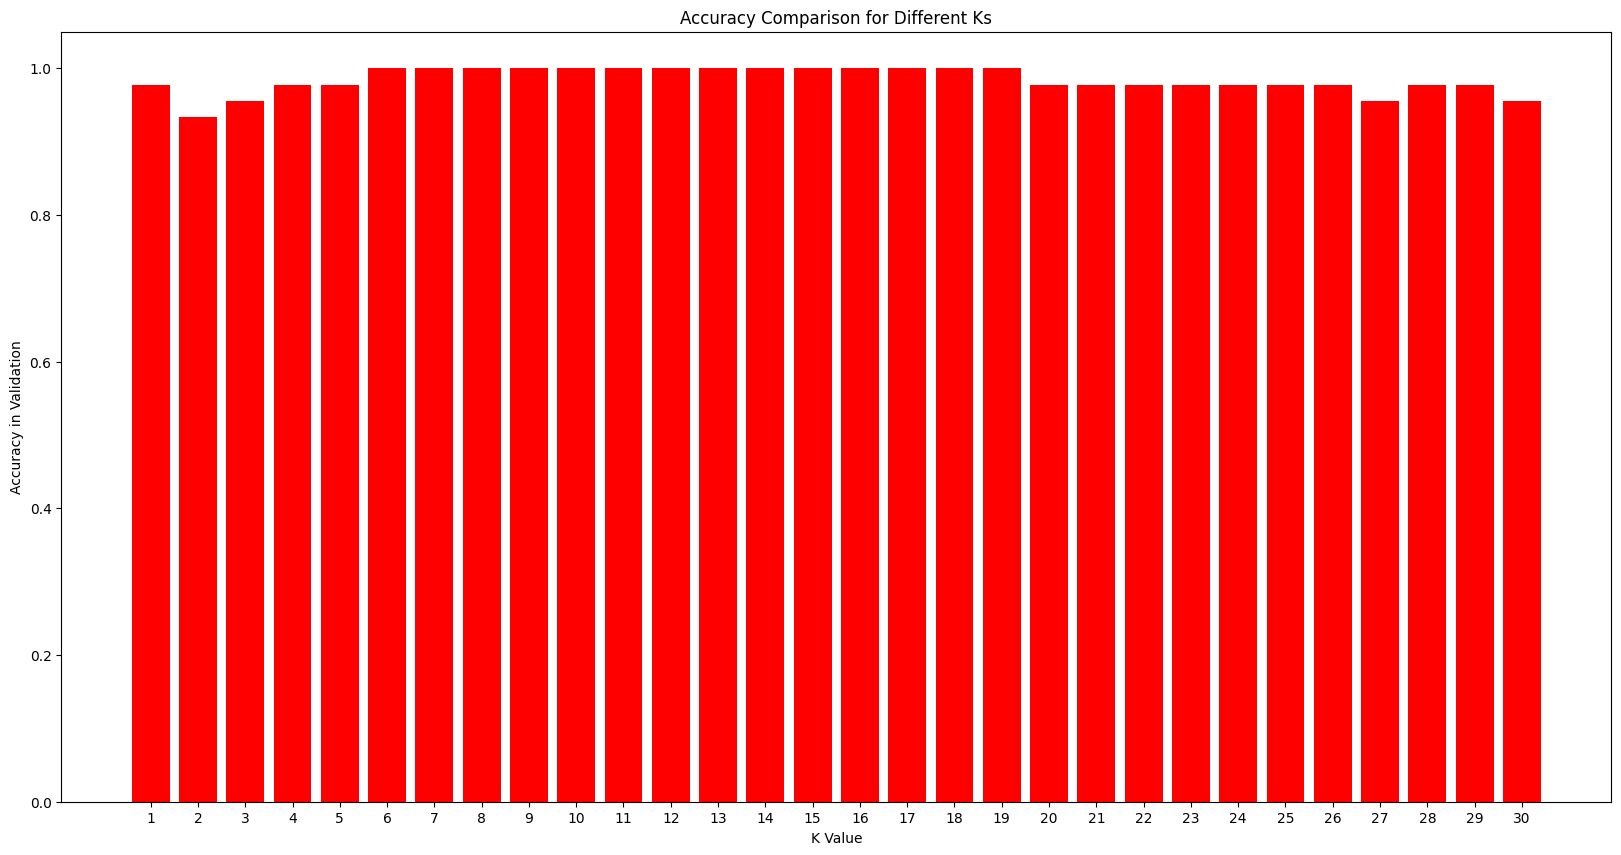

In [14]:
plt.figure(figsize=(20, 10))
plt.bar(ks, accs, color='red')
plt.xlabel('K Value')
plt.ylabel('Accuracy in Validation')
plt.title('Accuracy Comparison for Different Ks')
plt.xticks(ks)
plt.show()

Joint the train set with validation, to predict for the test set. Use a bar plot to show the overall accuraccy an the accuracy per class

Accuracy en test:  0.9111111111111111
Class 0 accuracy:  1.0
Class 1 accuracy:  1.0
Class 2 accuracy:  0.6923076923076923


Text(0, 0.5, 'Accuracy')

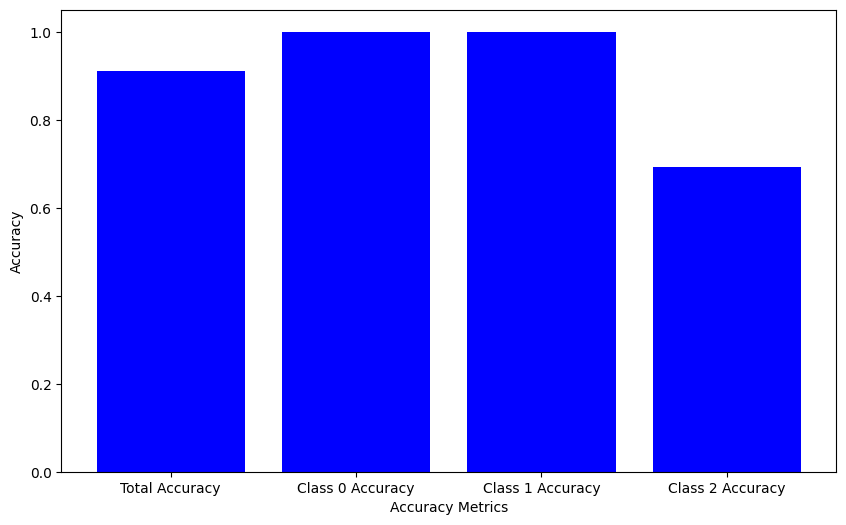

In [15]:
Xtrain2 = np.concatenate((X_train, X_val), axis=0)
ytrain2 = np.concatenate((y_train, y_val), axis=0)

final_pred = myKNN(Xtrain2, ytrain2, X_test, best_k)
total_acc, acc_0, acc_1, acc_2 = acc(final_pred, y_test)
print("Accuracy en test: ", total_acc)
print("Class 0 accuracy: ", acc_0)
print("Class 1 accuracy: ", acc_1)
print("Class 2 accuracy: ", acc_2)

array_plot = [total_acc, acc_0, acc_1, acc_2]
labels = ['Total Accuracy', 'Class 0 Accuracy', 'Class 1 Accuracy', 'Class 2 Accuracy']
plt.figure(figsize=(10, 6))
plt.bar(labels, array_plot, color='blue')
plt.xlabel('Accuracy Metrics')
plt.ylabel('Accuracy')


Plot the training points using circles and using different colors for different classes. Plot the test points using stars, use different colors for different predicted classes. Add legend, title and labels for the x and y axis. You chose which features to use for the 2D plot.

/tmp/ipykernel_19654/3635566505.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(classes))


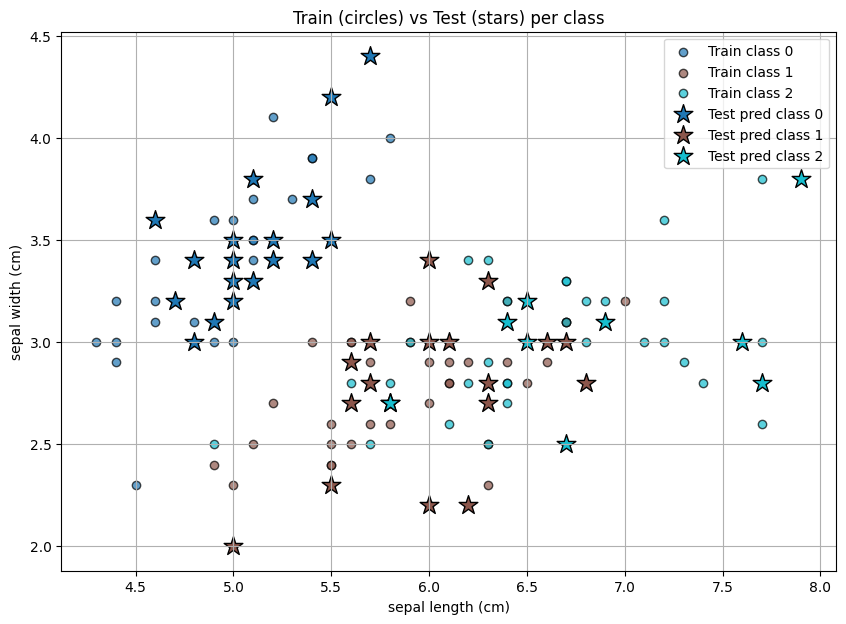

In [16]:
axis = [0, 1]  # <- Here I choose which features to compare
classes = [0,1,2]
colors = plt.cm.get_cmap('tab10', len(classes))
plt.figure(figsize=(10, 7))

for class_id in classes:
    idx = (ytrain2 == class_id)
    plt.scatter(
        Xtrain2[idx, axis[0]],
        Xtrain2[idx, axis[1]],
        c=[colors(class_id)],
        label=f'Train class {class_id}',
        marker='o',
        edgecolors='black',
        alpha=0.7
    )

for class_id in classes:
    idx = (final_pred == class_id)
    plt.scatter(
        X_test[idx, axis[0]],
        X_test[idx, axis[1]],
        c=[colors(class_id)],
        label=f'Test pred class {class_id}',
        marker='*',
        s=200,
        edgecolors='black'
    )
plt.title('Train (circles) vs Test (stars) per class')
plt.xlabel(f'{data.feature_names[axis[0]]}')
plt.ylabel(f'{data.feature_names[axis[1]]}')
plt.legend()
plt.grid(True)
plt.show()